# Premier League Transfer Value Predictor

Predicts a current Premier League player's market value from their stats (goals, assists, minutes, age & position). The data is scraped from Transfermarkt (via Kaggle) and covers many leagues and many years; we filter it down to players active in the Premier League over the last two seasons.

## 1. Load & inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("data")
PL_CODE = "GB1"
TARGET = "market_value_in_eur"
PLAYERS_CSV = DATA_DIR / "players.csv"
APPEARANCES_CSV = DATA_DIR / "appearances.csv"
VALUATIONS_CSV = DATA_DIR / "player_valuations.csv"
AS_OF_DATE = pd.Timestamp("2026-06-30")
MIN_LAST_SEASON = 2024

The dataset comes from three separate CSV files. We load `players.csv` (one row per player, with the market value we want to predict) and `appearances.csv` (one row per player per game, i.e. an appearance, holding goals/assists/minutes). From `appearances.csv` we only read the 5 columns we need and parse `date_of_birth` from `players.csv` as a date so we can compute age later.

In [2]:
players = pd.read_csv(PLAYERS_CSV, parse_dates=["date_of_birth"])
appearances = pd.read_csv(
    APPEARANCES_CSV,
    usecols=["player_id", "competition_id", "goals", "assists", "minutes_played"],
)

First we check how many rows and columns there are in the players table. Then we check what type each column is. Finally, we check how many values are missing. The three columns that matter here are `position` (which thankfully isn't missing any), `date_of_birth` and the target `market_value_in_eur`.

In [3]:
print(players.shape)
print(players.dtypes)
print(players.isna().sum())

(50149, 26)
player_id                                        int64
first_name                                         str
last_name                                          str
name                                               str
last_season                                      int64
current_club_id                                  int64
player_code                                        str
country_of_birth                                   str
city_of_birth                                      str
country_of_citizenship                             str
date_of_birth                           datetime64[us]
sub_position                                       str
position                                           str
foot                                               str
height_in_cm                                   float64
contract_expiration_date                           str
agent_name                                         str
image_url                                          st

## 2. Filter to the Premier League

The raw data covers many leagues and we only want players from the Premier League. Transfermarkt's competition code for the PL is `GB1`. Note that recently relegated clubs are included too, not just the current 20.

After filtering to only the PL rows, we check the number of rows and columns again.

In [4]:
pl_players = players[players["current_club_domestic_competition_id"] == PL_CODE]
pl_players.shape

(2259, 26)

The PL code also matches players whose last club was in the PL but who have since retired (like Michael Owen). So we keep only players active in the last two seasons (since 2024) so age lines up with a real current value rather than a stale one.

In [5]:
pl_players = pl_players[pl_players["last_season"] >= MIN_LAST_SEASON]
pl_players.shape

(973, 26)

## 3. Cleaning

Now we want to drop the PL players who either don't have the target `market_value_in_eur` (no value = nothing to learn) or `date_of_birth` (we need a birthday for the age feature).

First let's see how bad it is.

In [6]:
pl_players[[TARGET, "date_of_birth"]].isna().sum()

market_value_in_eur    170
date_of_birth            0
dtype: int64

Thankfully no PL players have a missing date of birth. Let's now drop those without the target and see the no. of rows and columns again. Note that `date_of_birth` technically isn't needed in the below statement for the above reason but we're adding it as a defensive measure for if the dataset ever changes.

In [7]:
pl_players = pl_players.dropna(subset=[TARGET, "date_of_birth"])
pl_players.shape

(803, 26)

## 4. Build the age feature

Now let's compute the age column by subtracting each player's date of birth from a fixed reference date. We use mid-2026, roughly when the market values were last recorded, so a player's age lines up with the value we predict. It is fixed rather than today's date on purpose, otherwise the ages would change on every re-run and could contradict the outputs saved in this notebook.

Afterwards we display the 1st 5 rows with name, birthday and age so we can check it looks right.

In [8]:
pl_players["age"] = (AS_OF_DATE - pl_players["date_of_birth"]).dt.days / 365.25
pl_players[["name", "date_of_birth", "age"]].head()

,name,date_of_birth,age
189,James Milner,1986-01-04,40.484600
1151,Ashley Young,1985-07-09,40.974675
1196,Scott Carson,1985-09-03,40.821355
1388,Casemiro,1992-02-23,34.349076
2516,Lukasz Fabianski,1985-04-18,41.199179


## 5. Add match stats (goals, assists, minutes)

Now let's keep only the PL appearances, excluding ones in all other competitions.

In [9]:
pl_appearances = appearances[appearances["competition_id"] == PL_CODE]

Let's now sum each player's stats. We group them by their `player_id`, aggregate the sums of each stat and combine them back into one row per group.

In [10]:
player_stats = (
    pl_appearances.groupby("player_id")[["goals", "assists", "minutes_played"]]
    .sum()
    .reset_index()
)

Now we do a left join of the `player_stats` DataFrame onto players (keeps all players, even ones with 0 PL appearances) by matching the rows with a shared `player_id`.

If any stat is missing, we fill those blanks with 0s.

In [11]:
pl_players = pl_players.merge(player_stats, on="player_id", how="left")

pl_players[["goals", "assists", "minutes_played"]] = pl_players[
    ["goals", "assists", "minutes_played"]
].fillna(0)

Finally, we drop the ones with 0 minutes played. The model predicts value based on performances, so a player without any has nothing to learn from.

In [12]:
pl_players = pl_players[pl_players["minutes_played"] > 0]
pl_players.shape

(661, 30)

## 6. Validate the assembled data

Now let's assert the assumptions we have relied on, to catch bad data before it reaches the model.

In [13]:
assert pl_players[TARGET].notna().all()  # target is complete
assert pl_players["position"].notna().all()  # no missing positions
assert pl_players["age"].between(15, 45).all()  # only active players remain
assert pl_players["player_id"].is_unique  # no duplicated rows
print("Data validation passed.")

Data validation passed.


## 7. Explore the data

Before modelling, we look at the data starting with the target since its shape decides how we should model it.

We plot the distribution of market values across the 661 players.

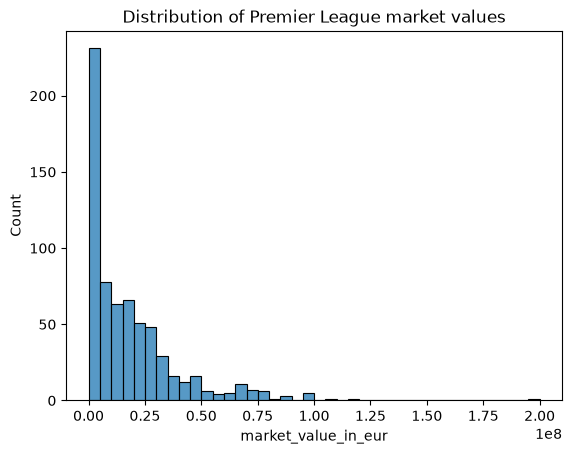

In [14]:
sns.histplot(pl_players[TARGET], bins=40)
plt.title("Distribution of Premier League market values")
plt.show()

The values are heavily right-skewed. Most players are worth only a few million and few are worth 100m+. This is a problem for linear regression, which minimises squared error and so would get pulled toward those few huge values and fit the majority worse.

A common fix is to model the log of the value instead of the raw value. Taking a log squashes the long tail, so below we plot the values on a log scale and see a more symmetric shape.

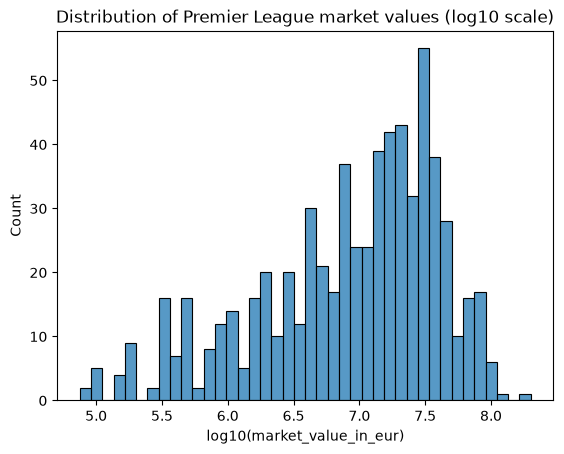

In [15]:
sns.histplot(np.log10(pl_players[TARGET]), bins=40)
plt.title("Distribution of Premier League market values (log10 scale)")
plt.xlabel("log10(market_value_in_eur)")
plt.show()

On the log scale, the distribution is far more symmetric and bell-shaped. Each step on the axis is a factor of 10 in euros: 5.0 is 100k, 6.0 is 1m, 7.0 is 10m and 8.0 is 100m. So when we build the model, we will predict the log of the market value rather than the raw value, and then convert back to euros for the result.

Next we look at how the numeric features relate to each other and to the market value. A correlation runs from -1 to +1 and measures how strongly two columns move together. We read the `market_value_in_eur` row to see which stats track with value.

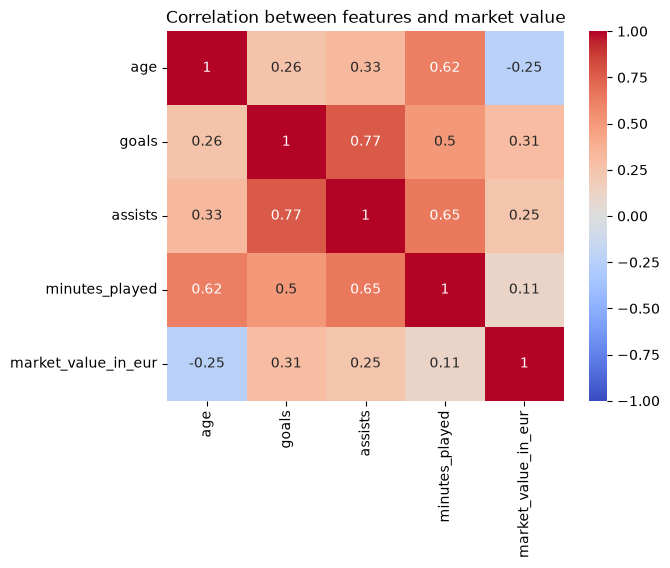

In [16]:
corr = pl_players[["age", "goals", "assists", "minutes_played", TARGET]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between features and market value")
plt.show()

The correlations with market value are weak: goals is the strongest at 0.31, then assists at 0.25, while minutes is almost flat at 0.11. Age is negative at -0.25 since older players tend to be worth less.

Two things stand out:
1. The features correlate to each other (goals and assists at 0.77, minutes and age at 0.62), which makes individual coefficients harder to read later.
2. Career minutes barely track value because veterans pile up minutes while their value falls, while young stars have high value with only few minutes. 

Weak correlations here hint that a simple linear model will explain only part of market value, which we will confirm against a baseline.

Finally, we plot value against two features directly, goals and age. Because value is so skewed (spans €100k to €200M), we put the value y-axis on a log scale so that the pattern is visible rather than every point except the superstars getting squashed together at the bottom.

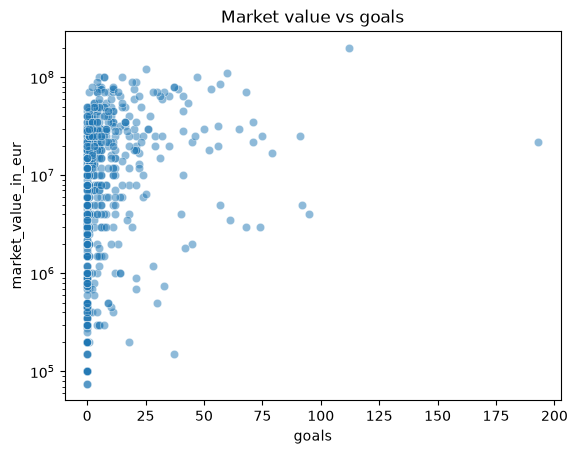

In [17]:
# Value vs goals
sns.scatterplot(data=pl_players, x="goals", y=TARGET, alpha=0.5)
plt.yscale("log")
plt.title("Market value vs goals")
plt.show()

The above plot has a tall column of players at 0 goals spanning the whole value range. Many valuable players are defenders, holding midfielders and goalkeepers who rarely score, so goals alone tracks value weakly. This is a strong hint that we also need position as a feature.

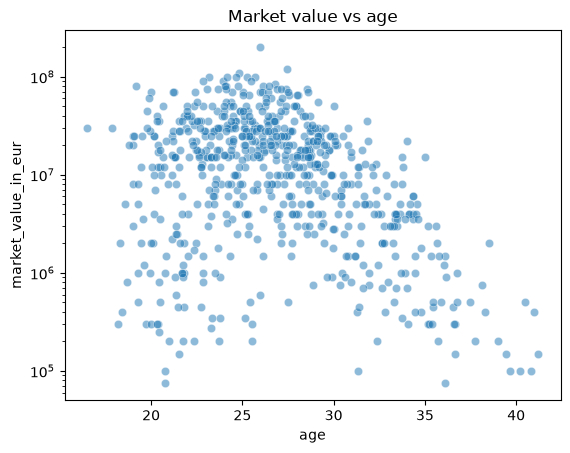

In [18]:
# Value vs age
sns.scatterplot(data=pl_players, x="age", y=TARGET, alpha=0.5)
plt.yscale("log")
plt.title("Market value vs age")
plt.show()

The age plot has a clear hump: value rises through the early twenties, peaks around 24 to 27 and then falls steeply after 32. This shape is a problem for linear regression, which fits a straight line and so can only capture the overall downward drift, not the rise then fall. It hints that age would be better modelled with a curve, for example an age-squared term, which is noted as a possible improvement.